--- REGRESSION EVALUATION METRICS ---
Mean Absolute Error (MAE): 7.8758
Root Mean Squared Error (RMSE): 11.0077
R-squared (R² Score):        0.7074

--- FEATURE COEFFICIENTS ---
       Feature  Weight (Coefficient)
9   FamilySize              2.887076
4        SibSp              2.498301
0     Survived              1.456734
5        Parch              0.388775
3          Age              0.032270
8   Age_scaled              0.000406
2          Sex             -1.024465
10     IsAlone             -3.927444
6   Embarked_Q             -3.976291
7   Embarked_S             -5.321896
1       Pclass            -17.064696


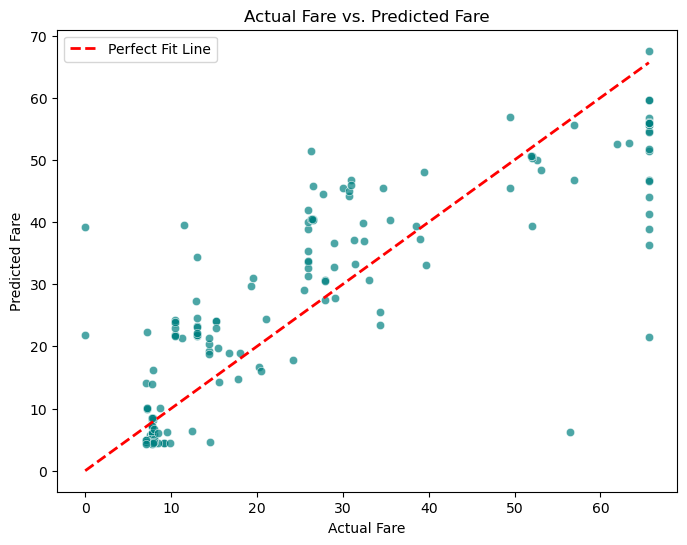

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =====================================================================
# STEP 1: Load Cleaned Dataset & Define Target
# =====================================================================
df = pd.read_csv('cleaned_titanic_dataset.csv')

# Determine the exact column name used for Fare in your file
target_col = 'Fare' if 'Fare' in df.columns else 'Fare_scaled'

# Isolate features (X) and target (y)
# Drop BOTH raw Fare and scaled Fare from X so the model actually has to guess!
X = df.drop(columns=['Fare', 'Fare_scaled', 'Name', 'Ticket', 'PassengerId'], errors='ignore')

# Target is what you want to predict
y = df['Fare'] # or df['Fare_scaled']

# Select only numerical features to prevent string errors
X = X.select_dtypes(include=['int64', 'float64', 'int32', 'uint8'])

# =====================================================================
# STEP 2: Train-Test Split (80/20)
# =====================================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =====================================================================
# STEP 3: Train Linear Regression Model
# =====================================================================
model = LinearRegression()
model.fit(X_train, y_train)

# =====================================================================
# STEP 4: Make Predictions
# =====================================================================
y_pred = model.predict(X_test)

# =====================================================================
# STEP 5: Evaluate Model Performance
# =====================================================================
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- REGRESSION EVALUATION METRICS ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R² Score):        {r2:.4f}")

# Display feature impact
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Weight (Coefficient)': model.coef_
}).sort_values(by='Weight (Coefficient)', ascending=False)

print("\n--- FEATURE COEFFICIENTS ---")
print(coef_df)

# =====================================================================
# STEP 6: Visualize Actual vs. Predicted Fares
# =====================================================================
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit Line')
plt.title("Actual Fare vs. Predicted Fare")
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.legend()
plt.show()